<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/Insurance_Charges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Analysis of Insurance Charges

In [ ]:
!pip install pregress

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.8 MB/s eta 0:00:00


In [ ]:
import pregress as pr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pr.get_data("Charges.csv")
df.drop("ID", axis=1, inplace=True)
df.head()

,Age,BMI,Plan,Sex,Smoke,Income,Charges
0,59,26.97,2,male,N,77965.0000,126966.7743
1,68,26.48,1,female,N,61048.0000,118915.9842
2,73,25.59,2,female,N,42460.0000,108496.4245
3,61,33.69,1,male,Y,84107.0000,302738.5223
4,79,25.15,3,male,Y,136426.4714,129749.9500


In [ ]:
# Convert plan to categorical
df["Plan"] = df["Plan"].astype("category")

## Convert to Dummy variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,BMI,Income,Charges,Plan_2,Plan_3,Sex_male,Smoke_Y
0,59,26.97,77965.0000,126966.7743,True,False,True,False
1,68,26.48,61048.0000,118915.9842,False,False,False,False
2,73,25.59,42460.0000,108496.4245,True,False,False,False
3,61,33.69,84107.0000,302738.5223,False,False,True,True
4,79,25.15,136426.4714,129749.9500,False,True,True,True


## Split the data

In [ ]:
df.shape

(1000, 8)

In [ ]:
X = df.drop("Charges", axis=1)
y = df["Charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(43556.29552991058)

In [ ]:
rmse = np.sqrt(np.mean((y_train - y_pred)**2))
rmse

## Fit a KNN Model

In [ ]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train_sc, y_train)

KNeighborsRegressor()

In [ ]:
y_pred = knn.predict(X_test_sc)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(36884.87955294875)

## Repeat using MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

In [ ]:
knn = KNeighborsRegressor()
knn.fit(X_train_mm, y_train)

y_pred = knn.predict(X_test_mm)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(39475.91711914307)

## Find Best K

In [ ]:
from sklearn.model_selection import cross_val_score
rmse = []
for i in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=i)
    cv_score = cross_val_score(knn, X_train_mm, y_train, cv=5, scoring = "neg_mean_squared_error")
    rmse.append(np.sqrt(-np.mean(cv_score)))

In [ ]:
best_k = np.argmin(rmse) + 1
best_k

np.int64(3)

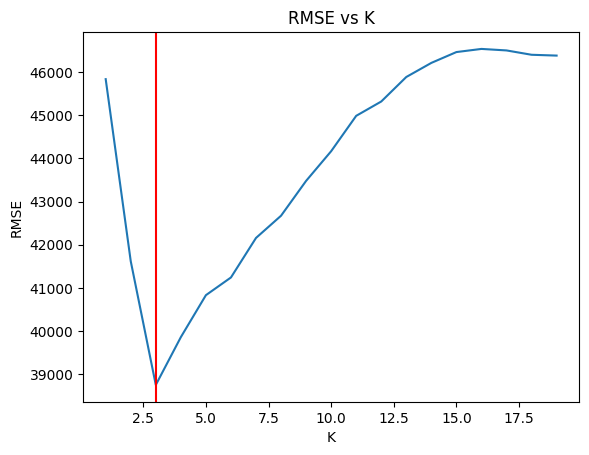

In [ ]:
plt.plot(range(1, 20), rmse)
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("RMSE vs K")
plt.axvline(best_k, color="red")
plt.show()

In [ ]:
knn_best_mm = KNeighborsRegressor(n_neighbors=best_k)
knn_best_mm.fit(X_train_mm, y_train)

y_pred = knn_best_mm.predict(X_test_mm)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(37638.45485135839)

## Redo with Standard Scaler

In [ ]:
rmse2 = []
for i in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=i)
    cv_score = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring = "neg_mean_squared_error")
    rmse2.append(np.sqrt(-np.mean(cv_score)))

In [ ]:
best_k2 = np.argmin(rmse2) + 1
best_k2

np.int64(3)

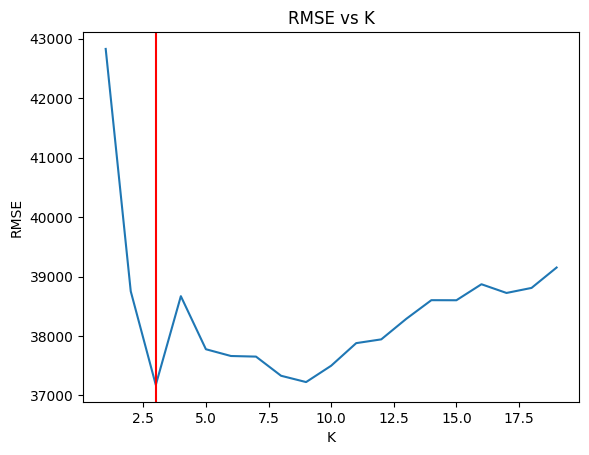

In [ ]:
plt.plot(range(1, 20), rmse2)
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("RMSE vs K")
plt.axvline(best_k2, color="red")
plt.show()

In [ ]:
knn_best_sc = KNeighborsRegressor(n_neighbors=best_k2)
knn_best_sc.fit(X_train_sc, y_train)

KNeighborsRegressor(n_neighbors=np.int64(3))

In [ ]:
y_pred = knn_best_sc.predict(X_test_sc)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(35979.47888230438)

# Don't Disregard the EDA

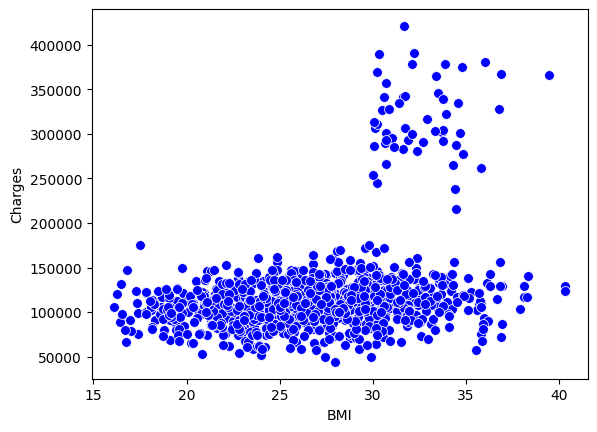

In [ ]:
pr.plot_xy("Charges ~ BMI", data = df)

In [ ]:
pd.concat([y_train, X_train], axis=1)

,Charges,Age,BMI,Income,Plan_2,Plan_3,Sex_male,Smoke_Y
29,81598.60487,60,24.656704,114890.45650,False,True,True,False
535,105118.74110,79,23.150000,47835.00000,True,False,False,False
695,120880.87940,71,25.850000,137133.37950,False,True,False,False
557,146309.67460,62,28.050000,118921.57700,False,True,False,True
836,119255.91260,63,26.640000,89245.00000,False,False,True,False
...,...,...,...,...,...,...,...,...
106,108761.82190,71,25.110000,75590.00000,True,False,False,False
270,123615.59800,61,29.200000,121772.19820,False,True,False,True
860,97530.28498,73,26.920000,51702.00000,True,False,False,False
435,111760.46270,81,30.410000,131283.92990,False,True,False,False


In [ ]:
X_train['BMI_risk'] = (X_train['BMI'] > 30).astype(int)
X_test['BMI_risk'] = (X_test['BMI'] > 30).astype(int)

In [ ]:
model = pr.fit("Charges ~ Age + BMI + Age:BMI_risk:Smoke_Y", data = pd.concat([y_train, X_train], axis=1))
pr.summary(model)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                            coef   std err       t     P>|t|     
Intercept             46740.0000  7087.857   6.594  0.000000  ***
Age                     663.6633    82.497   8.045  0.000000  ***
BMI                     695.6494   172.429   4.034  0.000000  ***
Age:BMI_risk:Smoke_Y   3143.9377    52.817  59.525  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.8378                AIC: 18194.4960
Adj. R-squared: 0.8372           BIC: 18213.2344
F-statistic: 1370.34 on 3 and 796 DF, p-value: 0.000000


In [ ]:
y_pred = pr.predict(model, X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(22419.779179579178)

## Summary for GitHub

This notebook performs a machine learning analysis to predict insurance charges based on various demographic and health factors.

### Data Loading and Preprocessing
- The `Charges.csv` dataset was loaded using `pregress.get_data()`.
- The `ID` column was dropped.
- The `Plan` column was converted to a categorical type.
- Categorical variables (`Plan`, `Sex`, `Smoke`) were converted to dummy variables using `pd.get_dummies()`.

### Data Splitting
- The data was split into training and testing sets (80% train, 20% test).

### Model Training and Evaluation

#### 1. Linear Regression
- A `LinearRegression` model was trained.
- The RMSE on the test set was approximately `43556`.

#### 2. K-Nearest Neighbors (KNN)
- **Standard Scaler:**
    - `StandardScaler` was applied to the features.
    - A `KNeighborsRegressor` was trained.
    - The RMSE on the test set was approximately `36884`.
    - Cross-validation was performed to find the best `k` (number of neighbors), which was `3`.
    - With `k=3` and `StandardScaler`, the RMSE improved to approximately `35979`.

- **MinMax Scaler:**
    - `MinMaxScaler` was applied to the features.
    - A `KNeighborsRegressor` was trained.
    - The RMSE on the test set was approximately `39475`.
    - Cross-validation was performed to find the best `k`, which was also `3`.
    - With `k=3` and `MinMaxScaler`, the RMSE was approximately `37638`.

#### 3. Linear Regression with Feature Engineering (Interaction Term)
- An exploratory data analysis suggested a relationship between `Charges` and `BMI`.
- A new feature `BMI_risk` was created, indicating if BMI is greater than 30.
- A linear regression model was trained with an interaction term `Age:BMI_risk:Smoke_Y`.
- The formula used was `Charges ~ Age + BMI + Age:BMI_risk:Smoke_Y`.
- The `pr.summary()` showed highly significant coefficients for `Age`, `BMI`, and the interaction term.
- This model achieved a significantly lower RMSE on the test set of approximately `22419`.

### Conclusion
Adding the `BMI_risk` feature and an interaction term in a linear regression model drastically improved the prediction accuracy for insurance charges, outperforming both basic Linear Regression and K-Nearest Neighbors models (even after hyperparameter tuning for `k`). This highlights the importance of exploratory data analysis and feature engineering.